In [22]:
import os
import numpy as np
import pandas as pd
from scipy.special import expit as sigmoid
from scipy.stats import norm
from tqdm import tqdm
import matplotlib.pyplot as plt

import bayesflow as bf
from bayesflow.networks import InvertibleNetwork, DeepSet
from bayesflow.amortizers import AmortizedPosterior
from bayesflow.trainers import Trainer

In [23]:
# helper functions
def rmse(x, y):
    return np.sqrt(np.mean((x - y) ** 2))

def inverse_sigmoid(x: np.ndarray) -> np.ndarray:
    """Inverse of the sigmoid function."""
    return np.log(x) - np.log1p(-x)

- Create a true population with infections, get a biased sample from it
- The biased sample represents the data we would get from an actual study
- From the true population, we pretend to know only the distribution of the covariates (and the infectiousness related with these, in a real application, we would also estimate these)
- Hence, we can create an approximation of the true population by stratified sampling from the biased sample

In [56]:
# 1. Sampling from priors
def get_realistic_priors():
    """With these priors, the uncorrected prevalence will generally be too low compared to the true population prevalence. This is because the sampling mechanism systematically underrepresents high-risk groups and overrepresents low-risk groups.
    The corrected prevalence using inverse probability weighting should compensate for this by giving more weight to the underrepresented high-risk groups, resulting in a higher and more accurate estimate of the true prevalence."""
    # Infection model priors
    infection_prior_means = {
        'intercept': -2.0,      # Base infection rate around 12% (logit-1(-2.0) ≈ 0.12)
        'age': 0.015,           # Moderate increase in infection risk with age
        'gender_female': -0.25, # Slightly lower risk for females
        'region_north': 0.4,    # Higher infection rate in north region
        'region_south': 0.1,    # Slightly higher in south
        'region_east': -0.1,    # Slightly lower in east
        'region_west': -0.3     # Lower in west
    }

    # Larger standard deviations for more diverse datasets
    infection_prior_stds = {
        'intercept': 0.8,       # Large uncertainty in base rate (prevalence from ~5% to ~25%)
        'age': 0.1,            # Moderate variability in age effect
        'gender_female': 0.4,   # High uncertainty in gender effect
        'region_north': 0.5,    # High uncertainty in regional effects
        'region_south': 0.5,
        'region_east': 0.5,
        'region_west': 0.5
    }

    # Inclusion model priors (sampling bias)
    inclusion_prior_means = {
        'intercept': -0.8,      # Base inclusion rate around 31% (logit-1(-0.8) ≈ 0.31)
        'age': 0.0,
        'gender_female': 0.5,   # Women more likely to participate
        'region_north': -0.4,   # Regional differences in participation
        'region_south': -0.2,
        'region_east': 0.3,
        'region_west': 0.5      # Higher participation in west
    }

    # Larger standard deviations for more diverse datasets
    inclusion_prior_stds = {
        'intercept': 0.6,       # Large uncertainty in base inclusion rate
        'age': 0.2,
        'gender_female': 0.35,  # High uncertainty in gender effect
        'region_north': 0.45,   # High uncertainty in regional effects
        'region_south': 0.45,
        'region_east': 0.45,
        'region_west': 0.45
    }

    return (infection_prior_means, infection_prior_stds,
            inclusion_prior_means, inclusion_prior_stds)

def sample_logit_models_from_priors(
    infection_covariates, inclusion_covariates,
    infection_prior_means=None, infection_prior_stds=None,
    inclusion_prior_means=None, inclusion_prior_stds=None,
    default_mean=0.0, default_std=1.0, seed=None
):
    if seed is not None:
        np.random.seed(seed)

    def sample_params(covariates, means, stds):
        means = means or {}
        stds = stds or {}
        return {
            cov: np.random.normal(loc=means.get(cov, default_mean), scale=stds.get(cov, default_std))
            for cov in covariates
        }

    infection_params = sample_params(infection_covariates, infection_prior_means, infection_prior_stds)
    inclusion_params = sample_params(inclusion_covariates, inclusion_prior_means, inclusion_prior_stds)

    return infection_params, inclusion_params

In [57]:
# 2. Simulate a population
# Known population parameters
age_params = (50, 15)
gender_probs = {'male': 0.5, 'female': 0.5}
region_probs = {'north': 0.25, 'south': 0.25, 'east': 0.25, 'west': 0.25}

def simulate_population(
    n,
    infection_logit_params, inclusion_logit_params,
    oversample_factor=10,  # Simulate more to ensure enough inclusion diversity
    biased_sample=True,  # to get unbiased prevalence
):
    N_pool = n * oversample_factor

    # Step 1: simulate covariates
    age = np.random.normal(loc=age_params[0], scale=age_params[1], size=N_pool)
    age = np.clip(age, 0, 100)  # Age between 0 and 100
    gender = np.random.choice(list(gender_probs.keys()), size=N_pool, p=list(gender_probs.values()))
    region = np.random.choice(list(region_probs.keys()), size=N_pool, p=list(region_probs.values()))
    df = pd.DataFrame({'age': age, 'gender': gender, 'region': region})
    df_encoded = pd.get_dummies(df, drop_first=False)

    # Step 2: compute inclusion probs
    inclusion_logit = np.full(N_pool, inclusion_logit_params.get('intercept', 0.0))
    for k, v in inclusion_logit_params.items():
        if k == 'intercept':
            continue
        elif k == 'age':
            inclusion_logit += v * df['age']
        elif k in df_encoded.columns:
            inclusion_logit += v * df_encoded[k]
    inclusion_prob = sigmoid(inclusion_logit)
    df['inclusion_prob'] = inclusion_prob

    # Step 3: compute infection for individuals
    if not biased_sample:
        # Randomly assign infection status
        rand_prev = np.random.uniform(0.1, 0.6)
        df['infection'] = np.random.binomial(1, rand_prev, size=N_pool)
    else:
        # Compute infection logit
        infection_logit = np.full(N_pool, infection_logit_params.get('intercept', 0.0))
        df_encoded = pd.get_dummies(df[['age', 'gender', 'region']], drop_first=False)
        for k, v in infection_logit_params.items():
            if k == 'intercept':
                continue
            elif k == 'age':
                infection_logit += v * df['age']
            elif k in df_encoded.columns:
                infection_logit += v * df_encoded[k]
        df['infection'] = np.random.binomial(1, sigmoid(infection_logit))

    # Step 4: sample directly from inclusion distribution
    weights = inclusion_prob / inclusion_prob.sum()
    sampled_idx = np.random.choice(N_pool, size=n, replace=True, p=weights)
    df_sampled = df.iloc[sampled_idx].copy()
    df_sampled.pop('inclusion_prob')

    # Step 5: compute prevalence
    true_prev = df['infection'].mean()
    return df_sampled, true_prev

In [58]:
def estimate_inclusion_probs_from_known_population(df_sampled):
    """
    Estimate inclusion probabilities based on known population parameters.

    Args:
        df_sampled: The sampled dataframe

    Returns:
        Series of estimated inclusion probabilities
    """
    # Calculate weights for each observation
    weights = np.ones(len(df_sampled))

    # 1. Adjust for age distribution
    # Calculate expected age probability density for each observation's age
    # using the normal distribution with known parameters
    age_density_pop = norm.pdf(df_sampled['age'], loc=age_params[0], scale=age_params[1])
    weights *= age_density_pop / age_density_pop.sum()

    # 2. Adjust for gender distribution
    for gender, pop_prob in gender_probs.items():
        mask = df_sampled['gender'] == gender
        sample_prob = mask.mean()
        # If we have more of a certain gender in our sample than in the population,
        # we need to down-weight those observations
        weights[mask] *= (pop_prob / sample_prob) if sample_prob > 0 else 1

    # 3. Adjust for region distribution
    for region, pop_prob in region_probs.items():
        mask = df_sampled['region'] == region
        sample_prob = mask.mean()
        weights[mask] *= (pop_prob / sample_prob) if sample_prob > 0 else 1

    # Convert weights to inclusion probabilities
    # Higher weight means this observation represents more people in the population,
    # which implies lower inclusion probability
    weights = weights / weights.sum() * len(df_sampled)
    inclusion_probs = 1 / weights

    # Normalize inclusion probabilities to have a meaningful scale
    inclusion_probs = inclusion_probs / inclusion_probs.max()

    return inclusion_probs

# 3. Estimate prevalence
def estimate_prevalence(sampled_df, bootstrap=False):
    uncorrected = sampled_df['infection'].mean()
    sampled_df['inclusion_prob_estimated'] = estimate_inclusion_probs_from_known_population(sampled_df)
    weights = 1 / sampled_df['inclusion_prob_estimated']
    corrected = np.average(sampled_df['infection'], weights=weights)
    uncorrected = np.clip(uncorrected, 0, 1)
    corrected = np.clip(corrected, 0, 1)
    if bootstrap:
        bootstrap_estimates = bootstrap_prevalence(sampled_df)
        bootstrap_estimates = np.clip(bootstrap_estimates, 0, 1)
        return uncorrected, corrected, bootstrap_estimates
    else:
        return uncorrected, corrected


def bootstrap_prevalence(sampled_df, n_bootstrap=100, random_state=None):
    """
    Use bootstrapping to estimate weighted prevalence.

    Parameters:
    -----------
    sampled_df : DataFrame
        DataFrame containing 'infection' and 'inclusion_prob' columns
    n_bootstrap : int, optional
        Number of bootstrap samples (default: 100)
    random_state : int or None, optional
        Random seed for reproducibility

    Returns:
    --------
        bootstrap samples
    """
    # Set random seed if provided
    if random_state is not None:
        np.random.seed(random_state)

    # Create array to store bootstrap estimates
    bootstrap_estimates = np.zeros(n_bootstrap)

    # Perform bootstrap resampling
    n = len(sampled_df)
    for i in range(n_bootstrap):
        # Generate bootstrap sample with replacement
        indices = np.random.choice(n, size=n, replace=True)
        bootstrap_sample = sampled_df.iloc[indices].copy()
        bootstrap_sample['inclusion_prob'] = estimate_inclusion_probs_from_known_population(bootstrap_sample)

        # Calculate weighted prevalence for this bootstrap sample
        bootstrap_weights = 1 / bootstrap_sample['inclusion_prob']
        bootstrap_estimates[i] = np.average(bootstrap_sample['infection'], weights=bootstrap_weights)
    return bootstrap_estimates

In [59]:
infection_prior_means, infection_prior_stds, inclusion_prior_means, inclusion_prior_stds = get_realistic_priors()

# 4. Run simulation study
def run_simulation_study(
    n_runs=500, sample_target=200, biased_sample=True
):
    infection_covs = ['intercept', 'age', 'gender_female', 'region_north']
    inclusion_covs = ['intercept', 'age', 'gender_female', 'region_west']
    uncorrected_prevalences = []
    corrected_prevalences = []
    true_prevalences = []
    bootstrap_prevalences = []

    for i in tqdm(range(n_runs)):
        infection_params, inclusion_params = sample_logit_models_from_priors(
            infection_covariates=infection_covs,
            inclusion_covariates=inclusion_covs,
            infection_prior_means=infection_prior_means,
            infection_prior_stds=infection_prior_stds,
            inclusion_prior_means=inclusion_prior_means,
            inclusion_prior_stds=inclusion_prior_stds,
            seed=i
        )
        df_sampled, true_prev = simulate_population(
            n=sample_target,
            infection_logit_params=infection_params,
            inclusion_logit_params=inclusion_params,
            biased_sample=biased_sample
        )

        uncor, cor, bootstrap = estimate_prevalence(df_sampled, bootstrap=True)

        true_prevalences.append(true_prev)
        uncorrected_prevalences.append(uncor)
        corrected_prevalences.append(cor)
        bootstrap_prevalences.append(bootstrap)

    return np.array(uncorrected_prevalences), np.array(corrected_prevalences), np.array(true_prevalences), np.array(bootstrap_prevalences)

# Run and plot
uncor_prev, cor_prev, true_prev, bootstrap_prev = run_simulation_study()

100%|██████████| 500/500 [00:38<00:00, 13.12it/s]


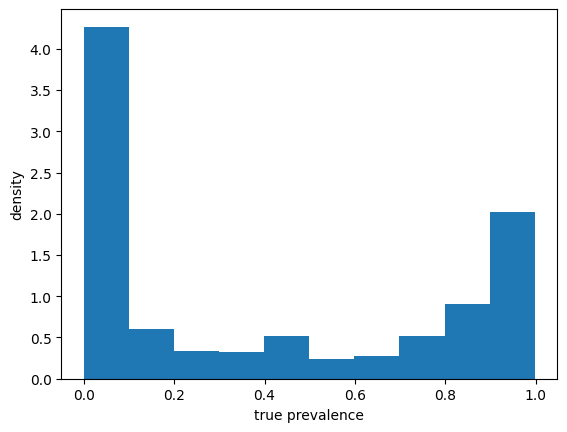

In [62]:
plt.hist(true_prev, density=True)
plt.xlabel('true prevalence')
plt.ylabel('density')
plt.show()

RMSE: 0.11620976689418364
Biased RMSE: 0.18849430362745714


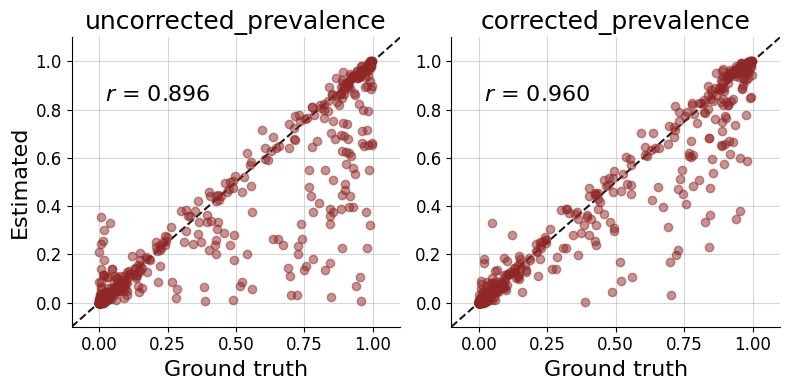

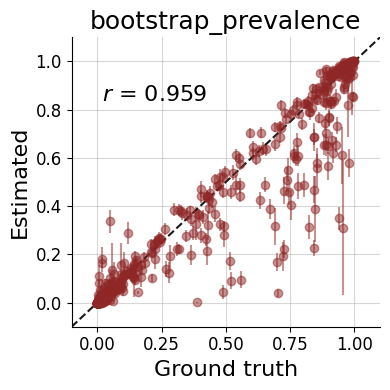

In [65]:
bf.diagnostics.plot_recovery(np.concatenate((uncor_prev[:, np.newaxis, np.newaxis], cor_prev[:, np.newaxis, np.newaxis]), axis=-1),
                             np.stack((true_prev, true_prev), axis=-1),
                             param_names=['uncorrected_prevalence', 'corrected_prevalence'], add_r2=False)
bf.diagnostics.plot_recovery(bootstrap_prev[..., np.newaxis], true_prev[..., np.newaxis],
                             param_names=['bootstrap_prevalence'], add_r2=False)

rmse_uncor = rmse(uncor_prev, true_prev)
rmse_cor = rmse(cor_prev, true_prev)
print(f"RMSE: {rmse_cor}")
print(f"Biased RMSE: {rmse_uncor}")

In [66]:
column_names = ['age', 'infection', 'gender_female', 'region_north', 'region_south', 'region_west']

In [67]:
def convert_to_nn_input(new_population: pd.DataFrame) -> np.ndarray:
    new_population_nn = pd.get_dummies(new_population, drop_first=False)
    # add zero columns if missing
    new_population_nn = new_population_nn.reindex(columns=column_names, fill_value=0)
    new_population_nn = new_population_nn.values * 1
    new_population_nn[:, 0] = new_population_nn[:, 0] / 100  # normalize age
    return new_population_nn

In [84]:
param_names = ['prevalence']
infection_covs = ['intercept', 'age', 'gender_female', 'region_north']
inclusion_covs = ['intercept', 'age', 'gender_female', 'region_west']

def generative_model(batch_size, pop_size=200, bootstrap=False):
    if pop_size is None:
        pop_size = np.random.uniform(100, 1000)

    out_dict = {
        'pop_size': pop_size,
        'sim_data': np.zeros((batch_size, pop_size, 6)),
        'prior_draws': np.zeros((batch_size, len(param_names))),
        'reference': np.zeros((batch_size, 1)),
        'reference_biased': np.zeros((batch_size, 1)),
        'reference_bootstrap': np.zeros((batch_size, 100, 1)),
        'bias_sample': np.zeros((batch_size, 1), dtype=bool)
    }
    for b in range(batch_size):
        while True:
            infection_params, inclusion_params = sample_logit_models_from_priors(
                infection_covariates=infection_covs,
                inclusion_covariates=inclusion_covs,
                infection_prior_means=infection_prior_means,
                infection_prior_stds=infection_prior_stds,
                inclusion_prior_means=inclusion_prior_means,
                inclusion_prior_stds=inclusion_prior_stds
            )

            # generate a new population
            new_population, true_prev = simulate_population(
                n=pop_size,
                infection_logit_params=infection_params,
                inclusion_logit_params=inclusion_params,
                biased_sample=True
            )
            if 0.01 < true_prev < 0.99:
                # only use sample where something is happening
                break
        if bootstrap:
            uncor, cor, b_estimates = estimate_prevalence(new_population, bootstrap=True)
            out_dict['reference_bootstrap'][b] = b_estimates[:, np.newaxis]
        else:
            uncor, cor = estimate_prevalence(new_population, bootstrap=False)

        # save the data and parameters
        out_dict['sim_data'][b] = convert_to_nn_input(new_population)
        out_dict['prior_draws'][b] = true_prev
        out_dict['reference_biased'][b] = uncor
        out_dict['reference'][b] = cor
        out_dict['bias_sample'][b] = (true_prev - uncor)**2 > 0.05
    return out_dict

In [87]:
np.random.seed(42)
#epsilon = 1e-15
lower = 0. #- epsilon  # exclusive bound
upper = 1. #+ epsilon  # exclusive bound

valid_data = generative_model(300, bootstrap=True)
p_draws_unconstrained = valid_data['prior_draws']
#p_draws_unconstrained = inverse_sigmoid((p_draws_unconstrained - lower) / (upper - lower))
prior_mean = np.mean(p_draws_unconstrained, axis=0)
prior_std = np.std(p_draws_unconstrained, axis=0)

def configurator(forward_dict: dict) -> dict:
    # Extract data
    out_dict = {
        'summary_conditions': forward_dict["sim_data"].astype(np.float32),
        #'inference_conditions': np.ones((forward_dict["sim_data"].shape[0], 1), dtype=np.float32) * forward_dict["pop_size"] / 1000
    }

    # Extract params
    if 'parameters' in forward_dict.keys():
        forward_dict["prior_draws"] = forward_dict["parameters"]
    if 'prior_draws' in forward_dict.keys():
        params = forward_dict["prior_draws"]
        #params = inverse_sigmoid((params - lower) / (upper - lower))
        params = (params - prior_mean) / prior_std
        out_dict['parameters'] = params.astype(np.float32)
    return out_dict

def configurator_inverse(forward_dict) -> dict:
    if isinstance(forward_dict, np.ndarray):
        params = forward_dict
        params = params * prior_std + prior_mean
        #params = (upper - lower) * sigmoid(params) + lower
        return params

    # Extract params
    if 'parameters' in forward_dict.keys():
        forward_dict["prior_draws"] = forward_dict["parameters"]
    if 'prior_draws' in forward_dict.keys():
        params = forward_dict["prior_draws"]
        params = params * prior_std + prior_mean
        #params = (upper - lower) * sigmoid(params) + lower
        forward_dict["parameters"] = params
    return forward_dict

In [88]:
valid_data['bias_sample'].sum()

47

In [92]:
summary_net = DeepSet(
    summary_dim=10,
    dense_s1_args={"units": 128, "activation": "relu", "kernel_initializer": "glorot_uniform"},
    dense_s2_args={"units": 128, "activation": "relu", "kernel_initializer": "glorot_uniform"},
    dense_s3_args={"units": 128, "activation": "relu", "kernel_initializer": "glorot_uniform"},
)

inference_net = InvertibleNetwork(
    num_params=len(param_names),
    num_coupling_layers=5
)
amortizer = AmortizedPosterior(
    inference_net=inference_net,
    summary_net=summary_net,
)

In [93]:
trainer = Trainer(
    amortizer=amortizer,
    configurator=configurator,
    generative_model=generative_model,
    checkpoint_path='amortizer_prevalence',
)

INFO:root:Initialized empty loss history.
INFO:root:Initialized networks from scratch.
INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


In [94]:
if trainer.checkpoint_path is None or not os.path.exists(trainer.checkpoint_path):
    history = trainer.train_online(
        epochs=20,
        batch_size=32,
        iterations_per_epoch=100,
        early_stopping=True,
        validation_sims=valid_data
    )
else:
    trainer.load_pretrained_network()
    history = trainer.loss_history.get_plottable()

Training epoch 1:   0%|          | 0/100 [00:00<?, ?it/s]

INFO:root:Validation, Epoch: 1, Loss: 0.144


Training epoch 2:   0%|          | 0/100 [00:00<?, ?it/s]

INFO:root:Validation, Epoch: 2, Loss: 0.594


Training epoch 3:   0%|          | 0/100 [00:00<?, ?it/s]

...

INFO:root:Validation, Epoch: 18, Loss: -0.882


Training epoch 19:   0%|          | 0/100 [00:00<?, ?it/s]

INFO:root:Validation, Epoch: 19, Loss: -0.881


Training epoch 20:   0%|          | 0/100 [00:00<?, ?it/s]

INFO:root:Validation, Epoch: 20, Loss: -0.879


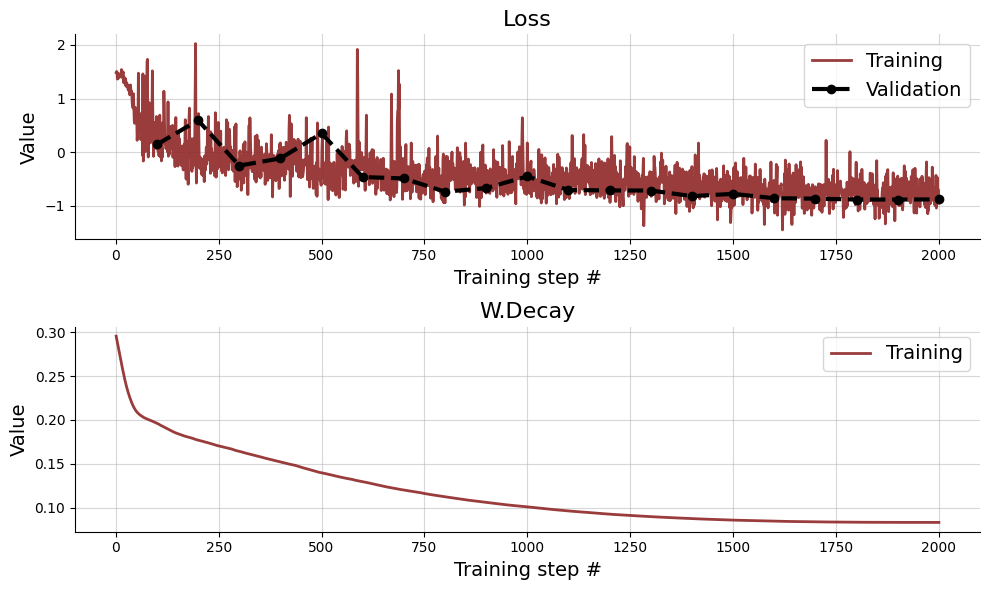

In [99]:
bf.diagnostics.plot_losses(history['train_losses'], history['val_losses'], fig_size=(10, 6));

In [100]:
posterior_samples = trainer.amortizer.sample(trainer.configurator(valid_data), n_samples=100)
posterior_samples = configurator_inverse(posterior_samples)

RMSE BayesFlow: 0.10139898280178197
Corrected RMSE: 0.1298795099447099
Biased RMSE: 0.184072734718281


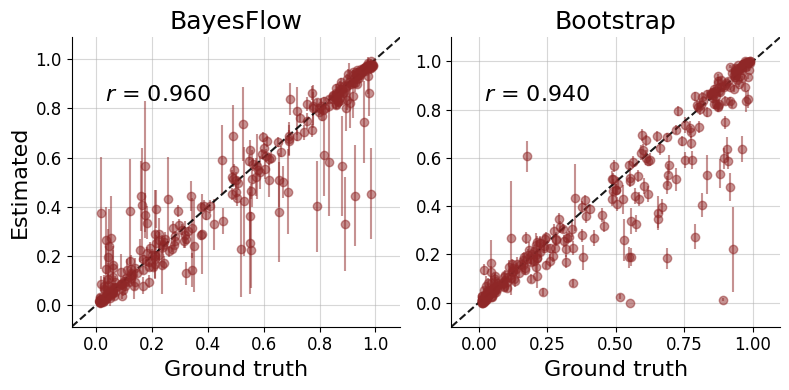

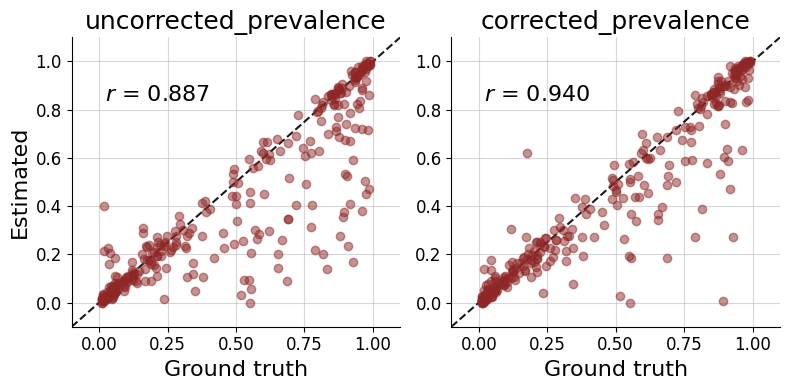

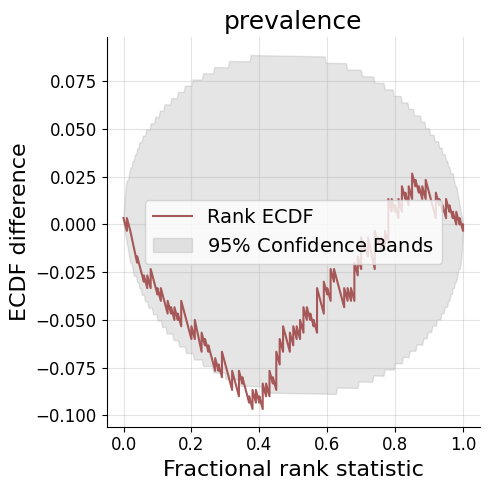

In [101]:
bf.diagnostics.plot_recovery(np.concatenate((posterior_samples, valid_data['reference_bootstrap']), axis=-1),
                             np.concatenate((valid_data['prior_draws'], valid_data['prior_draws']), axis=-1),
                             param_names=['BayesFlow', 'Bootstrap'], add_r2=False)

# bf.diagnostics.plot_recovery(np.concatenate((posterior_samples, valid_data['reference_bootstrap']), axis=-1),
#                              np.concatenate((valid_data['reference'], valid_data['reference']), axis=-1),
#                              param_names=['BayesFlow', 'Bootstrap'], add_r2=False)

bf.diagnostics.plot_recovery(np.concatenate((valid_data['reference_biased'][:, np.newaxis],
                                             valid_data['reference'][:, np.newaxis]), axis=-1),
                             np.concatenate((valid_data['prior_draws'], valid_data['prior_draws']), axis=-1),
                             param_names=['uncorrected_prevalence', 'corrected_prevalence'], add_r2=False)

bf.diagnostics.plot_sbc_ecdf(posterior_samples, valid_data['prior_draws'], difference=True, param_names=param_names)

rmse_bf = rmse(np.median(posterior_samples, axis=1), valid_data['prior_draws'])
rmse_cor = rmse(valid_data['reference'], valid_data['prior_draws'])
rmse_uncor = rmse(valid_data['reference_biased'], valid_data['prior_draws'])
print(f"RMSE BayesFlow: {rmse_bf}")
print(f"Corrected RMSE: {rmse_cor}")
print(f"Biased RMSE: {rmse_uncor}")

RMSE BayesFlow: 0.10139898280178197
Corrected RMSE: 0.1298795099447099
Biased RMSE: 0.184072734718281


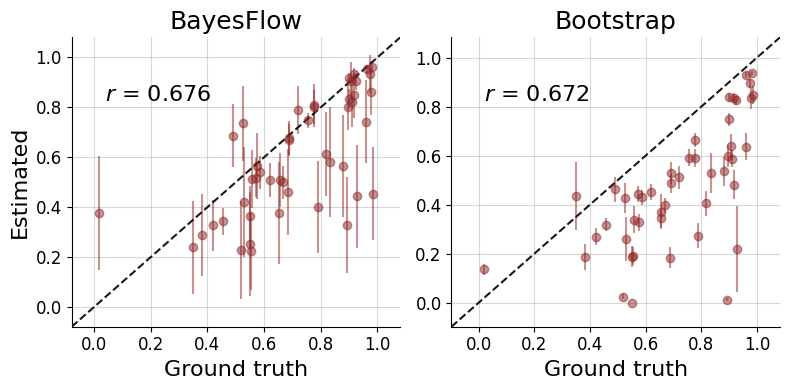

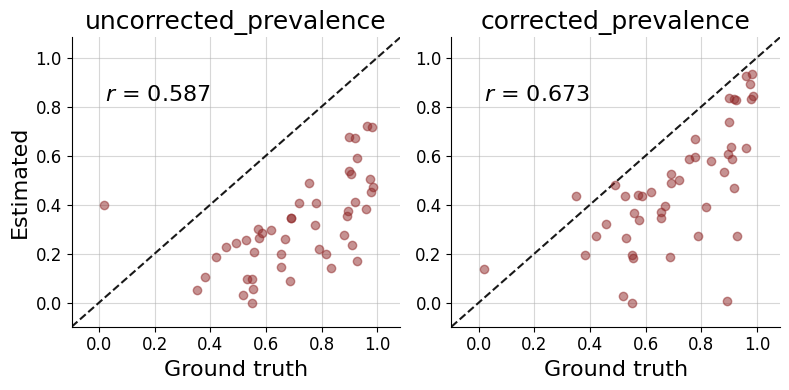

In [103]:
# only plot really biased samples
bf.diagnostics.plot_recovery(np.concatenate((posterior_samples, valid_data['reference_bootstrap']), axis=-1)[valid_data['bias_sample'].flatten()],
                             np.concatenate((valid_data['prior_draws'], valid_data['prior_draws']), axis=-1)[valid_data['bias_sample'].flatten()],
                             param_names=['BayesFlow', 'Bootstrap'], add_r2=False)


bf.diagnostics.plot_recovery(np.concatenate((valid_data['reference_biased'][:, np.newaxis],
                                             valid_data['reference'][:, np.newaxis]), axis=-1)[valid_data['bias_sample'].flatten()],
                             np.concatenate((valid_data['prior_draws'], valid_data['prior_draws']), axis=-1)[valid_data['bias_sample'].flatten()],
                             param_names=['uncorrected_prevalence', 'corrected_prevalence'], add_r2=False)

rmse_bf = rmse(np.median(posterior_samples, axis=1), valid_data['prior_draws'])
rmse_cor = rmse(valid_data['reference'], valid_data['prior_draws'])
rmse_uncor = rmse(valid_data['reference_biased'], valid_data['prior_draws'])
print(f"RMSE BayesFlow: {rmse_bf}")
print(f"Corrected RMSE: {rmse_cor}")
print(f"Biased RMSE: {rmse_uncor}")